Data Preparation

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("synthetic_financial_data.csv")

# Drop non-predictive columns
df_model = df.drop(columns=["CustomerID", "LoanPurposeDescription"])

# Separate target and features
X = df_model.drop("LoanDefault", axis=1)
y = df_model["LoanDefault"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

Train-Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Model 1: Basic Logistic Regression (Baseline Model)

In [3]:
from sklearn.linear_model import LogisticRegression

logreg_basic = LogisticRegression(max_iter=1000)
logreg_basic.fit(X_train, y_train)


c:\Users\My HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

Evaluation – Model 1

In [4]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_pred_basic = logreg_basic.predict(X_test)
y_prob_basic = logreg_basic.predict_proba(X_test)[:,1]

acc_basic = accuracy_score(y_test, y_pred_basic)
f1_basic = f1_score(y_test, y_pred_basic)
roc_basic = roc_auc_score(y_test, y_prob_basic)

acc_basic, f1_basic, roc_basic


(0.78, 0.8, np.float64(0.8425925925925926))

Underfitting Model

In [8]:
from sklearn.linear_model import LogisticRegression

logreg_underfit = LogisticRegression(
    C=0.01,          # very strong regularization
    max_iter=1000
)
logreg_underfit.fit(X_train, y_train)


c:\Users\My HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.01, max_iter=1000)

Evaluation underfitting model

In [9]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_under = logreg_underfit.predict(X_test)

acc_under = accuracy_score(y_test, y_pred_under)
f1_under = f1_score(y_test, y_pred_under)

acc_under, f1_under


(0.78, 0.8035714285714286)

OVERFITTING MODEL

In [10]:
logreg_overfit = LogisticRegression(
    C=100,           # very weak regularization
    max_iter=1000
)
logreg_overfit.fit(X_train, y_train)


c:\Users\My HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=100, max_iter=1000)

Evaluation overfitting model

In [11]:
y_pred_over = logreg_overfit.predict(X_test)

acc_over = accuracy_score(y_test, y_pred_over)
f1_over = f1_score(y_test, y_pred_over)

acc_over, f1_over


(0.775, 0.7963800904977375)

OPTIMAL FITTING MODEL

In [12]:
logreg_optimal = LogisticRegression(
    C=0.5,           # balanced regularization
    max_iter=1000
)
logreg_optimal.fit(X_train, y_train)


c:\Users\My HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.5, max_iter=1000)

Evaluation optimal model

In [13]:
y_pred_opt = logreg_optimal.predict(X_test)

acc_opt = accuracy_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

acc_opt, f1_opt


(0.775, 0.7982062780269058)

Model Interpretation

In [15]:
from sklearn.metrics import accuracy_score, f1_score

# Dictionary of trained models
models = {
    "Underfitting (C=0.01)": logreg_underfit,
    "Baseline (C=1.0)": logreg_basic,
    "Optimal (C=0.5)": logreg_optimal,
    "Overfitting (C=100)": logreg_overfit
}

# Store evaluation results
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, f1])

# Create summary table
import pandas as pd

evaluation_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "F1-score"]
)

evaluation_df


,Model,Accuracy,F1-score
0,Underfitting (C=0.01),0.780,0.803571
1,Baseline (C=1.0),0.780,0.800000
2,Optimal (C=0.5),0.775,0.798206
3,Overfitting (C=100),0.775,0.796380


Model Interpretation: Feature Importance (Optimal Model)

In [16]:
# Feature importance from optimal model
feature_importance = pd.Series(
    logreg_optimal.coef_[0],
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


InterestRate                    0.211513
ExistingLoans                   0.047060
EmploymentType_Unemployed       0.018643
PropertyOwnership_Rent          0.014558
EmploymentSector_Other          0.011246
Age                             0.008162
EmploymentType_Part-Time        0.007048
EmploymentType_Self-Employed    0.005796
Education_Below High School     0.005790
LoanPurpose_Education           0.005280
dtype: float64

Plot feature importance

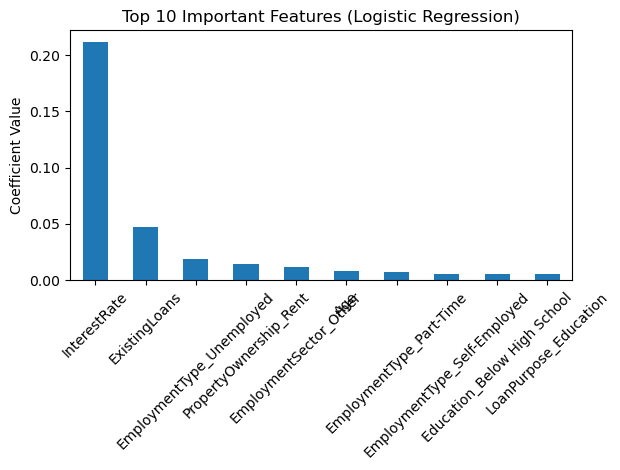

In [17]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features (Logistic Regression)")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Training vs Testing Performance   

In [18]:
def evaluate_train_test(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    return train_acc, test_acc

train_test_results = []

for name, model in models.items():
    train_acc, test_acc = evaluate_train_test(
        model, X_train, y_train, X_test, y_test
    )
    train_test_results.append([name, train_acc, test_acc])

train_test_df = pd.DataFrame(
    train_test_results,
    columns=["Model", "Train Accuracy", "Test Accuracy"]
)

train_test_df


,Model,Train Accuracy,Test Accuracy
0,Underfitting (C=0.01),0.7575,0.780
1,Baseline (C=1.0),0.7575,0.780
2,Optimal (C=0.5),0.7550,0.775
3,Overfitting (C=100),0.7600,0.775
